In [5]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Specifications
fs = 10000        # Sampling frequency (Hz)
cutoff = 1000     # Cutoff frequency (Hz)
num_taps = 100    # Number of filter taps

# Normalize cutoff frequency (0 to 1, where 1 = fs/2)
nyquist = fs / 2
normalized_cutoff = cutoff / nyquist

# Design the filter (equivalent to MATLAB's fir1)
filter_coefficients = signal.firwin(num_taps, normalized_cutoff)

# Display the coefficients
print("Filter Coefficients:")
print(filter_coefficients)


Filter Coefficients:
[-1.59218611e-04 -4.30359456e-04 -5.61775255e-04 -4.89840873e-04
 -2.05138661e-04  2.27954566e-04  6.69705997e-04  9.35068105e-04
  8.57842323e-04  3.72230362e-04 -4.22936842e-04 -1.25690281e-03
 -1.76050993e-03 -1.61030624e-03 -6.93627792e-04  7.80061826e-04
  2.29029732e-03  3.16604226e-03  2.85684092e-03  1.21395713e-03
 -1.34722713e-03 -3.90545357e-03 -5.33416973e-03 -4.75948674e-03
 -2.00167138e-03  2.20073166e-03  6.32676722e-03  8.57892909e-03
  7.60816073e-03  3.18414006e-03 -3.48824885e-03 -1.00061473e-02
 -1.35587458e-02 -1.20362473e-02 -5.05169320e-03  5.56163408e-03
  1.60719426e-02  2.20021749e-02  1.97997386e-02  8.45913864e-03
 -9.52904861e-03 -2.83612130e-02 -4.03338357e-02 -3.81486832e-02
 -1.74151873e-02  2.14846298e-02  7.28584291e-02  1.26785617e-01
  1.71588241e-01  1.96987400e-01  1.96987400e-01  1.71588241e-01
  1.26785617e-01  7.28584291e-02  2.14846298e-02 -1.74151873e-02
 -3.81486832e-02 -4.03338357e-02 -2.83612130e-02 -9.52904861e-03
  8.

In [6]:
def round_to_int(num):
    int_num = int(num) 
    frac = abs(num - int_num) 
    if frac >= 0.5:
        return int_num + 1 if num >= 0 else int_num - 1
    return int_num
def decToBinary(dec,m,n):
   return np.binary_repr(dec,m+n)
def fixedPoint(num, m, n):
  scale = 2**n
  fixed_int = round_to_int(num*scale)
  return decToBinary(fixed_int,m,n)
def quantize(samples,m,n):
  arr = []
  for i in range(len(samples)):
    arr.append(fixedPoint(samples[i],m,n))
  arr = np.array(arr,dtype=str)
  return arr

In [7]:
fc = np.array(filter_coefficients)
fc_quantized = quantize(fc,2,14)
np.savetxt('fc_quantized_2_14.txt',fc_quantized,fmt='%s')

In [8]:
ncycles = 100
def sampleVal(i,f,fs):
    Ts = 1/fs
    return np.sin(2*np.pi*f*i*Ts)
def sampleSineWave(f,fs,fname):
    arr = []
    t = np.arange(0,ncycles/f,1/fs)
    for i in range(len(t)):
        arr.append(sampleVal(i,f,fs))
    arr = np.array(arr)
    qarr = quantize(arr,2,14)
    np.savetxt(fname,qarr,fmt='%s')
def sampleSineWave_uq(f,fs,fname):
    t = np.arange(0,ncycles/f,1/fs)
    arr = []
    for i in range(len(t)):
        arr.append(sampleVal(i,f,fs))
    arr = np.array(arr)
    np.savetxt(fname,arr,fmt='%s')


In [9]:
fs = 10000
sampleSineWave(950,fs,"q_2_14_950.txt")
sampleSineWave(1100,fs,"q_2_14_1100.txt")
sampleSineWave(2000,fs,"q_2_14_2000.txt")
sampleSineWave_uq(950,fs,"q_2_14_950_uq.txt")

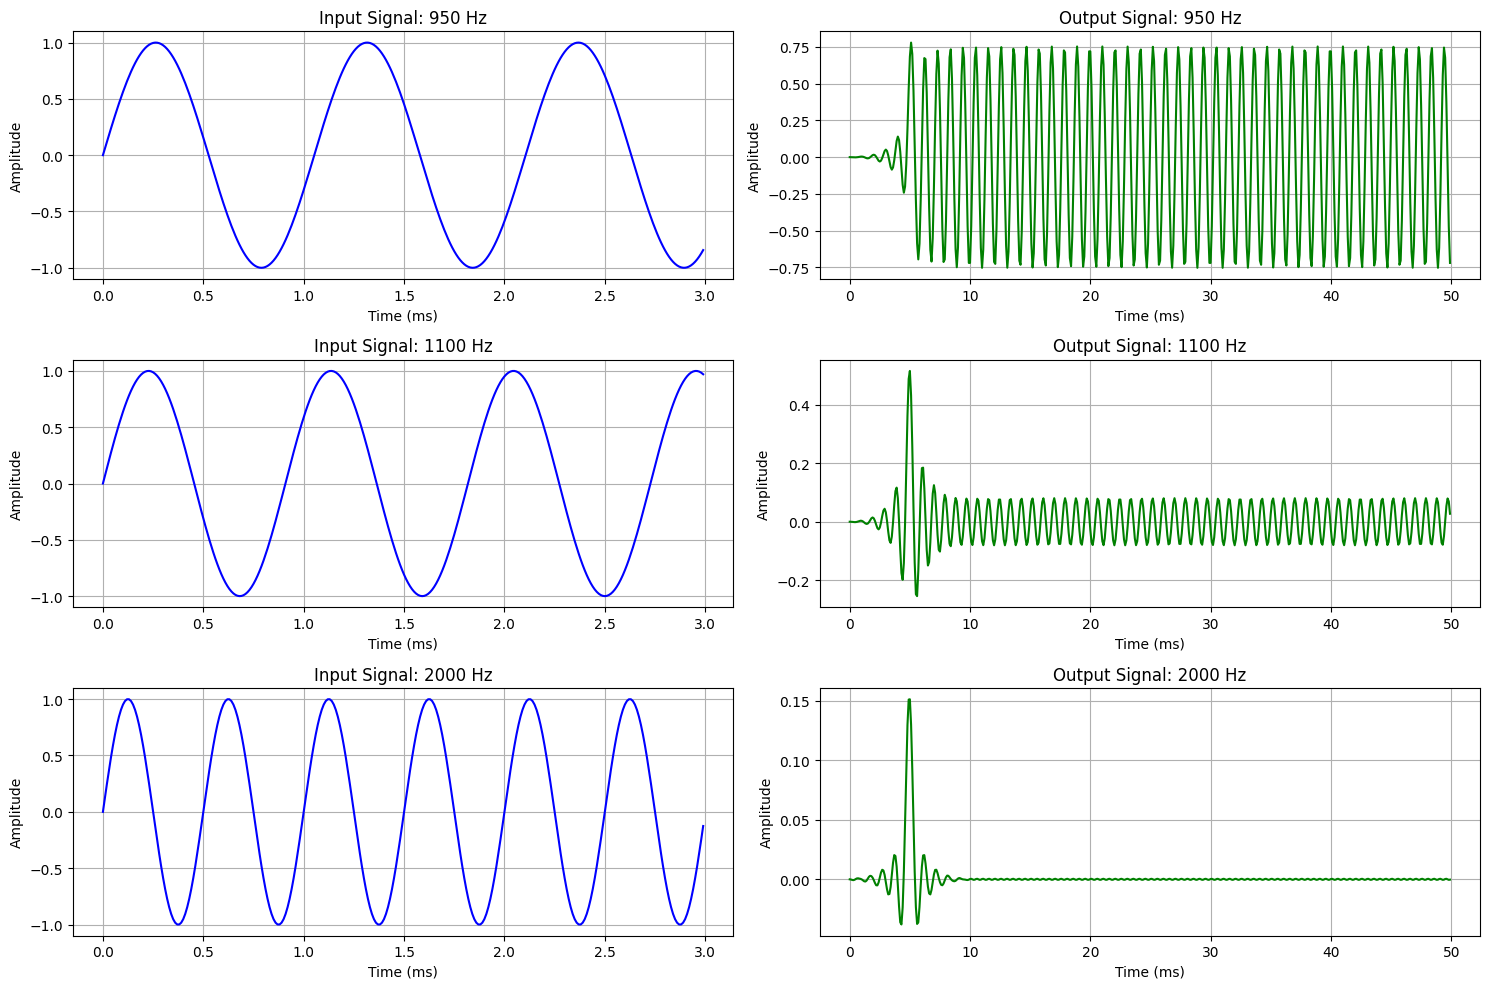

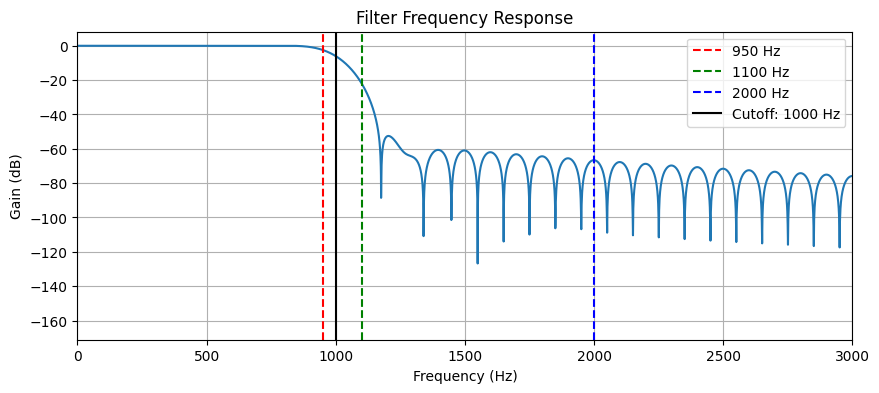

In [10]:
fs = 10000
freqs = [950, 1100, 2000]
outputs = []

# For FILTERING - use correct sampling rate
t_filter = np.arange(0, 0.05, 1/fs)  # 500 samples at 10kHz

# For PLOTTING - use high resolution (10x oversampling)
t_plot = np.arange(0, 0.05, 1/(fs*10))  # 5000 samples for smooth curves

plt.figure(figsize=(15, 10))

for i, f in enumerate(freqs):
    # Generate at FILTER rate for processing
    sine_wave_filter = np.sin(2 * np.pi * f * t_filter)
    
    # Apply filter
    output = signal.lfilter(filter_coefficients, 1, sine_wave_filter)
    outputs.append(output)
    # Generate at PLOT rate for smooth input display
    sine_wave_plot = np.sin(2 * np.pi * f * t_plot)
    
    # Plot smooth input
    plt.subplot(3, 2, 2*i + 1)
    plt.plot(t_plot[:300]*1000, sine_wave_plot[:300], 'b-')  # Smooth input
    plt.title(f'Input Signal: {f} Hz')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    
    # Plot output (at filter rate)
    plt.subplot(3, 2, 2*i + 2)
    plt.plot(t_filter[:500]*1000, output[:500], 'g-')
    plt.title(f'Output Signal: {f} Hz')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Frequency response (same as before)
plt.figure(figsize=(10, 4))
w, h = signal.freqz(filter_coefficients, worN=8000)
freq_hz = w * fs / (2 * np.pi)
plt.plot(freq_hz, 20 * np.log10(np.abs(h)))
plt.axvline(950, color='r', linestyle='--', label='950 Hz')
plt.axvline(1100, color='g', linestyle='--', label='1100 Hz')
plt.axvline(2000, color='b', linestyle='--', label='2000 Hz')
plt.axvline(1000, color='k', linestyle='-', label='Cutoff: 1000 Hz')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.title('Filter Frequency Response')
plt.grid(True)
plt.legend()
plt.xlim(0, 3000)
plt.show()

In [11]:
for i,f in enumerate(freqs):
    el = outputs[i]
    arr = []
    for i in range(500):
        arr.append(fixedPoint(el[i],4,28))
    arr = np.array(arr)
    np.savetxt(f'{f}_filtered.txt',arr,fmt='%s')

In [12]:
print(outputs[0])

[ 0.00000000e+00 -8.94941346e-05 -3.89935617e-04 -8.71286747e-04
 -1.32664448e-03 -1.43850204e-03 -9.24740238e-04  2.85263277e-04
  1.92219791e-03  3.37654073e-03  3.87236909e-03  2.79125600e-03
  3.83339599e-05 -3.71739882e-03 -7.09263703e-03 -8.40484245e-03
 -6.37186702e-03 -8.47914371e-04  6.74885974e-03  1.36173987e-02
  1.64588573e-02  1.28509496e-02  2.60349372e-03 -1.15425996e-02
 -2.43720419e-02 -2.98977915e-02 -2.38467285e-02 -5.99236959e-03
  1.87564569e-02  4.12949926e-02  5.13418677e-02  4.16720435e-02
  1.19661186e-02 -2.94993006e-02 -6.75280902e-02 -8.50425154e-02
 -7.00198326e-02 -2.17477996e-02  4.64125242e-02  1.09650698e-01
  1.39722141e-01  1.16116120e-01  3.64112669e-02 -7.85569957e-02
 -1.87799938e-01 -2.41883152e-01 -2.00237622e-01 -4.83896306e-02
  1.91457463e-01  4.61538026e-01  6.82724151e-01  7.78521083e-01
  7.01522075e-01  4.53173567e-01  8.90525452e-02 -2.93790154e-01
 -5.84817590e-01 -6.95035124e-01 -5.87553487e-01 -2.92814394e-01
  9.78351735e-02  4.59404

In [13]:
def twos_comp_to_int(binary_str):
    bits = len(binary_str)
    val = int(binary_str, 2)
    if binary_str[0] == '1': 
        val -= (1 << bits)
    return val

def int_to_twos_comp(val, bits):
    if val < 0:
        val += (1 << bits)
    return format(val, f'0{bits}b')

def val(str,scale):
      return twos_comp_to_int(str) / scale
def dequantize(arr, m, n):
    scale = 2**n
    out = []
    for i in range(len(arr)):
        str = arr[i]
        float_val = val(str,scale)
        out.append(float_val)
    
    return np.array(out)

bstr = '0010001111111001'

print(val(bstr,2**14))


0.56207275390625


In [14]:
def test(f,fs):
    t = np.arange(0,ncycles/f,1/fs)
    arr = []
    for i in range(len(t)):
        arr.append(sampleVal(i,f,fs))
    return  np.array(arr)

res = test(950,fs)

t_950 = np.arange(0,ncycles/950,1/fs)

sine_950 = np.sin(2 * np.pi * 950 * t_950)

out = signal.lfilter(filter_coefficients, 1, sine_950)


In [15]:
y = []
s_uq = np.loadtxt('q_2_14_950_uq.txt')
def x_n(i):
    if(i<0):return 0
    return res[i]

for i in range(500):
    y_n=0
    for j in range(100):
        y_n+=filter_coefficients[j]*x_n(i-j)
    y.append(y_n)

print(y)

[0.0, -8.949413455399371e-05, -0.0003899356172361708, -0.0008712867466335734, -0.001326644480926249, -0.0014385020430742277, -0.0009247402381922175, 0.00028526327745603315, 0.0019221979081268008, 0.0033765407326927454, 0.0038723690877384737, 0.002791255996545112, 3.8333959916247496e-05, -0.003717398818327009, -0.00709263703008961, -0.008404842449829308, -0.006371867023877325, -0.0008479143714712079, 0.0067488597402266025, 0.013617398745580715, 0.01645885733062214, 0.012850949623340668, 0.002603493724259878, -0.011542599593415236, -0.02437204191112586, -0.029897791458300904, -0.023846728461252648, -0.0059923695914419536, 0.018756456934060067, 0.041294992620950224, 0.05134186769000621, 0.04167204351148955, 0.011966118603306805, -0.02949930064161351, -0.06752809019390435, -0.08504251537038028, -0.0700198326383432, -0.021747799644088517, 0.04641252421517118, 0.10965069793954271, 0.13972214145025424, 0.11611612021066613, 0.03641126691641981, -0.0785569957111872, -0.18779993787491348, -0.241

In [16]:
out_950_quantized = np.loadtxt('out_950_verilog.txt',dtype=str)
out_950 = dequantize(out_950_quantized,4,28)
print(out_950)


[ 0.          0.          0.          0.          2.2481881   5.96687477
 -6.13003507 -3.39219661 -2.76655081 -6.7181596   2.11948561 -5.77684888
  4.32368949  2.46159589  7.52957744  1.77509642 -2.34486413  7.0612322
 -5.26007619  5.17000198 -7.72310881 -7.4806498  -4.65302683  5.31604477
 -5.23891737 -6.19893645 -2.7648485  -1.65752391  7.20517714  2.50841934
  1.87351168 -4.94739534  5.93769698 -6.16657072 -2.82281273 -1.18293662
 -7.34580337  1.75336749  1.43046939  0.01099284 -2.02073885  1.5682199
  4.60387562  1.10830254  0.07953845  1.88185649  0.36350993  0.98201815
 -7.55056557 -3.60799589 -4.56081491 -4.54064398  7.53779836 -3.85018161
  2.84539834 -1.05614002 -3.62632012  1.06913475  0.43683393  1.95083274
 -0.40270055 -5.79199374 -6.82343971  7.91383178 -0.33795317 -7.19380507
  5.72525602  1.97315846  3.80845951  1.80734202  1.61719455 -2.21568486
  7.63554698  6.82322877  4.4312432  -3.66419939  6.8497344   5.85277169
  4.13922954 -6.5312239  -7.08241614  7.59959299  0.4